# MMRAZ Red-Teaming Run Analysis (Full History + Judge)

This notebook analyzes the updated paper-style red-teaming loop against the GPT-2 layer-6 MM temporal probe.

It is intended for runs produced by the new loop with:
- a persistent attacker conversation history,
- a separate judge model providing ground-truth labels,
- per-round attacker and judge API usage logs.

Set `RUN_ID` in the next cell to analyze a specific run. Leave it as `None` to auto-select the latest run with judge artifacts.


In [39]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")


# Change only this variable to analyze a different run.
# Example: RUN_ID = "20260322-090107"
# RUN_ID = "20260322-090107"
RUN_ID = None


In [40]:
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(10):
        if (p / "pyproject.toml").exists() and (p / "out").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError("Could not locate repository root")


ROOT = find_repo_root(Path.cwd())
RUNS_ROOT = ROOT / "out" / "mmraz_intertemporal" / "adversarial_red_teaming" / "runs"


def resolve_run_dir(run_id) -> Path:
    if run_id is not None:
        run_dir = RUNS_ROOT / run_id
        if not run_dir.exists():
            raise FileNotFoundError(f"Run directory not found: {run_dir}")
        return run_dir

    candidates = []
    for path in RUNS_ROOT.iterdir():
        if not path.is_dir():
            continue
        has_new_schema = (path / "judge_api_usage.jsonl").exists() or any(path.glob("round_*_judge_evaluations.json"))
        if has_new_schema:
            candidates.append(path)
    if not candidates:
        raise FileNotFoundError(f"No updated red-teaming outputs found under {RUNS_ROOT}")
    return sorted(candidates)[-1]


def load_json_if_exists(path: Path):
    return json.loads(path.read_text()) if path.exists() else None


def load_jsonl(path: Path):
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]


def load_round_candidates(run_dir: Path) -> pd.DataFrame:
    frames = []
    for path in sorted(run_dir.glob("round_*_candidates.jsonl")):
        match = re.search(r"round_(\d+)_candidates\.jsonl$", path.name)
        if match is None:
            continue
        round_idx = int(match.group(1))
        rows = load_jsonl(path)
        if not rows:
            continue
        frame = pd.DataFrame(rows)
        frame["round_idx"] = round_idx
        frame["round_file"] = path.name
        frames.append(frame)

    if not frames:
        raise FileNotFoundError(f"No round candidate files found in {run_dir}")

    return (
        pd.concat(frames, ignore_index=True)
        .sort_values(["round_idx", "candidate_id"], kind="stable")
        .reset_index(drop=True)
    )


def load_api_usage(run_dir: Path, actor: str) -> pd.DataFrame:
    aggregate_path = run_dir / f"{actor}_api_usage.jsonl"
    if aggregate_path.exists():
        rows = load_jsonl(aggregate_path)
        if not rows:
            return pd.DataFrame()
        df = pd.DataFrame(rows)
        if "round_idx" in df.columns:
            df["iteration"] = df["round_idx"].where(df["round_idx"].notna(), pd.NA) + 1
        return df.sort_values(["request_type", "round_idx", "created_at"], kind="stable").reset_index(drop=True)

    rows = []
    for path in sorted(run_dir.glob(f"round_*_{actor}_api_usage.json")):
        payload = load_json_if_exists(path)
        if payload is None:
            continue
        match = re.search(rf"round_(\d+)_{actor}_api_usage\.json$", path.name)
        if match is not None and payload.get("round_idx") is None:
            payload["round_idx"] = int(match.group(1))
        rows.append(payload)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    if "round_idx" in df.columns:
        df["iteration"] = df["round_idx"].where(df["round_idx"].notna(), pd.NA) + 1
    return df.sort_values(["request_type", "round_idx", "created_at"], kind="stable").reset_index(drop=True)


def load_attacker_message_stats(run_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(run_dir.glob("round_*_attacker_request_messages.json")):
        match = re.search(r"round_(\d+)_attacker_request_messages\.json$", path.name)
        if match is None:
            continue
        round_idx = int(match.group(1))
        payload = load_json_if_exists(path)
        if not isinstance(payload, list):
            continue
        message_count = len(payload)
        user_turns = sum(1 for item in payload if isinstance(item, dict) and item.get("role") == "user")
        assistant_turns = sum(1 for item in payload if isinstance(item, dict) and item.get("role") == "assistant")
        total_chars = sum(len(str(item.get("content", ""))) for item in payload if isinstance(item, dict))
        json_chars = len(json.dumps(payload, ensure_ascii=True))
        rows.append(
            {
                "round_idx": round_idx,
                "iteration": round_idx + 1,
                "request_message_count": message_count,
                "request_user_turns": user_turns,
                "request_assistant_turns": assistant_turns,
                "request_total_chars": total_chars,
                "request_json_chars": json_chars,
            }
        )
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("round_idx").reset_index(drop=True)


run_dir = resolve_run_dir(RUN_ID)
run_config = load_json_if_exists(run_dir / "run_config.json") or {}
target_probe = load_json_if_exists(run_dir / "target_probe.json") or {}
final_summary = load_json_if_exists(run_dir / "final_summary.json") or {}
df = load_round_candidates(run_dir)
attacker_usage_df = load_api_usage(run_dir, "attacker")
judge_usage_df = load_api_usage(run_dir, "judge")
attacker_candidate_usage_df = (
    attacker_usage_df[attacker_usage_df.get("request_type", pd.Series(dtype=str)).eq("candidate_generation")].copy()
    if not attacker_usage_df.empty else pd.DataFrame()
)
judge_candidate_usage_df = (
    judge_usage_df[judge_usage_df.get("request_type", pd.Series(dtype=str)).eq("candidate_judging")].copy()
    if not judge_usage_df.empty else pd.DataFrame()
)
message_stats_df = load_attacker_message_stats(run_dir)

display(Markdown(f"**Run directory:** `{run_dir}`"))
display(Markdown(f"**Completed iterations found:** `{df['round_idx'].nunique()}`"))
display(Markdown(f"**Attacker API usage records found:** `{len(attacker_usage_df)}`"))
display(Markdown(f"**Judge API usage records found:** `{len(judge_usage_df)}`"))


**Run directory:** `/Users/michalmraz/code/spar-ai/temporal-awareness/out/mmraz_intertemporal/adversarial_red_teaming/runs/20260322-110736`

**Completed iterations found:** `19`

**Attacker API usage records found:** `20`

**Judge API usage records found:** `19`

In [41]:
df["probe_failed"] = df["is_adversarial_success"].astype(bool)
df["iteration"] = df["round_idx"] + 1
df["ground_truth_label"] = df["judge_label"] if "judge_label" in df.columns else df["intended_label"]
if "attacker_claimed_label" in df.columns:
    df["attacker_judge_agree"] = df["attacker_claimed_label"].eq(df["ground_truth_label"])
else:
    df["attacker_judge_agree"] = True
df["attacker_judge_disagree"] = ~df["attacker_judge_agree"].astype(bool)
df["failure_strength"] = np.where(
    df["ground_truth_label"].eq("long_term"),
    -df["probe_margin"],
    df["probe_margin"],
)

latest_attacker_usage = attacker_candidate_usage_df.sort_values("round_idx").tail(1) if not attacker_candidate_usage_df.empty else pd.DataFrame()
latest_judge_usage = judge_candidate_usage_df.sort_values("round_idx").tail(1) if not judge_candidate_usage_df.empty else pd.DataFrame()

overall_summary = pd.DataFrame([
    {
        "run_id": run_dir.name,
        "mode": final_summary.get("mode", "full_history_with_judge"),
        "expected_rounds": run_config.get("num_rounds"),
        "expected_candidates_per_round": run_config.get("candidates_per_round"),
        "completed_rounds": int(df["round_idx"].nunique()),
        "saved_candidates": int(len(df)),
        "probe_failures": int(df["probe_failed"].sum()),
        "overall_failure_rate": float(df["probe_failed"].mean()),
        "attacker_judge_disagreement_rate": float(df["attacker_judge_disagree"].mean()),
        "probe_model": target_probe.get("model_name"),
        "probe_layer": target_probe.get("layer"),
        "probe_test_accuracy": target_probe.get("test_accuracy"),
        "attacker_api_calls_logged": int(len(attacker_usage_df)),
        "judge_api_calls_logged": int(len(judge_usage_df)),
        "attacker_cumulative_total_request_tokens_used_so_far": (
            int(latest_attacker_usage["cumulative_total_request_tokens_used_so_far"].iloc[0])
            if not latest_attacker_usage.empty and "cumulative_total_request_tokens_used_so_far" in latest_attacker_usage.columns
            else None
        ),
        "judge_cumulative_total_request_tokens_used_so_far": (
            int(latest_judge_usage["cumulative_total_request_tokens_used_so_far"].iloc[0])
            if not latest_judge_usage.empty and "cumulative_total_request_tokens_used_so_far" in latest_judge_usage.columns
            else None
        ),
        "attacker_estimated_remaining_context_tokens": (
            int(latest_attacker_usage["estimated_remaining_context_tokens"].iloc[0])
            if not latest_attacker_usage.empty and "estimated_remaining_context_tokens" in latest_attacker_usage.columns
            else None
        ),
        "judge_estimated_remaining_context_tokens": (
            int(latest_judge_usage["estimated_remaining_context_tokens"].iloc[0])
            if not latest_judge_usage.empty and "estimated_remaining_context_tokens" in latest_judge_usage.columns
            else None
        ),
        "attacker_conversation_saved": (run_dir / "attacker_conversation.json").exists(),
        "final_summary_saved": (run_dir / "final_summary.json").exists(),
    }
])

display(overall_summary)

if not attacker_usage_df.empty:
    display(Markdown("**Attacker API usage records**"))
    usage_columns = [
        column
        for column in [
            "request_type",
            "round_idx",
            "input_tokens",
            "output_tokens",
            "total_request_tokens",
            "cumulative_total_request_tokens_used_so_far",
            "estimated_remaining_context_tokens",
            "context_window_tokens",
            "message_id",
        ]
        if column in attacker_usage_df.columns
    ]
    display(attacker_usage_df[usage_columns])

if not judge_usage_df.empty:
    display(Markdown("**Judge API usage records**"))
    usage_columns = [
        column
        for column in [
            "request_type",
            "round_idx",
            "input_tokens",
            "output_tokens",
            "total_request_tokens",
            "cumulative_total_request_tokens_used_so_far",
            "estimated_remaining_context_tokens",
            "context_window_tokens",
            "message_id",
        ]
        if column in judge_usage_df.columns
    ]
    display(judge_usage_df[usage_columns])


,run_id,mode,expected_rounds,expected_candidates_per_round,completed_rounds,saved_candidates,probe_failures,overall_failure_rate,attacker_judge_disagreement_rate,probe_model,probe_layer,probe_test_accuracy,attacker_api_calls_logged,judge_api_calls_logged,attacker_cumulative_total_request_tokens_used_so_far,judge_cumulative_total_request_tokens_used_so_far,attacker_estimated_remaining_context_tokens,judge_estimated_remaining_context_tokens,attacker_conversation_saved,final_summary_saved
0,20260322-110736,full_history_with_judge,20,10,19,190,95,0.5,0.005263,gpt2,6,0.88,20,19,562076,37184,144972,197920,False,False


**Attacker API usage records**

,request_type,round_idx,input_tokens,output_tokens,total_request_tokens,cumulative_total_request_tokens_used_so_far,estimated_remaining_context_tokens,context_window_tokens,message_id
0,candidate_generation,0,572,1546,2118,2118,197882,200000,msg_01B8VMk5QVZ6LpMk6KcJus2q
1,candidate_generation,1,3115,1604,4719,6837,195281,200000,msg_01F8oVcD2cGMNSj8hdcFFbmY
2,candidate_generation,2,5726,1570,7296,14133,192704,200000,msg_011E8x13xVFtDCd2yvWe8YMZ
3,candidate_generation,3,8356,1685,10041,24174,189959,200000,msg_01B3F8vcFr3j1SJQwdoupF9N
4,candidate_generation,4,11079,1685,12764,36938,187236,200000,msg_01NiWBZ1dpfARdCAfZPy39M4
5,candidate_generation,5,13844,1665,15509,52447,184491,200000,msg_014SDtaQhdYy6rLozUhnbxQY
6,candidate_generation,6,16540,1685,18225,70672,181775,200000,msg_01AHAWcCnAsH91nSQpPG6bo5
7,candidate_generation,7,19286,1658,20944,91616,179056,200000,msg_017qwH28mn197VmhWqaA4XXT
8,candidate_generation,8,21952,1707,23659,115275,176341,200000,msg_01Vq2sfaScpoPQvrDMemUHEF
9,candidate_generation,9,24788,1685,26473,141748,173527,200000,msg_01XcjgXnf6xuxuCt9KxAkQ5K


**Judge API usage records**

,request_type,round_idx,input_tokens,output_tokens,total_request_tokens,cumulative_total_request_tokens_used_so_far,estimated_remaining_context_tokens,context_window_tokens,message_id
0,candidate_judging,0,1246,627,1873,1873,198127,200000,msg_018eshxDFATz1SxkC6DvX8Zs
1,candidate_judging,1,1259,621,1880,3753,198120,200000,msg_01TV88g9vqoJU8vQoBXFa49j
2,candidate_judging,2,1237,681,1918,5671,198082,200000,msg_01GnXU9JTidmpWqCpN5xex9X
3,candidate_judging,3,1283,603,1886,7557,198114,200000,msg_011LKTMo7z1a4CK3RxYpv6SF
4,candidate_judging,4,1275,639,1914,9471,198086,200000,msg_01QZ7fcSzRQUjtxD1HzYAhsS
5,candidate_judging,5,1267,595,1862,11333,198138,200000,msg_019CHcLepeRmQbYxqsiDKMvW
6,candidate_judging,6,1279,621,1900,13233,198100,200000,msg_019NqNLb3DyZeCGip4TsseF6
7,candidate_judging,7,1276,578,1854,15087,198146,200000,msg_01BjYDxbfd8pXVgD87hSEi3B
8,candidate_judging,8,1303,687,1990,17077,198010,200000,msg_019wEmoYPQ6wTmS9L7oHAVjM
9,candidate_judging,9,1311,613,1924,19001,198076,200000,msg_014kaiLg8YgAqhwp7vrjAX1K


In [42]:
round_df = (
    df.groupby("round_idx", as_index=False)
    .agg(
        n_candidates=("candidate_id", "count"),
        n_failures=("probe_failed", "sum"),
        failure_rate=("probe_failed", "mean"),
        avg_probe_margin=("probe_margin", "mean"),
        avg_probe_confidence=("probe_confidence", "mean"),
        n_attacker_judge_disagree=("attacker_judge_disagree", "sum"),
        attacker_judge_disagree_rate=("attacker_judge_disagree", "mean"),
    )
    .sort_values("round_idx")
    .reset_index(drop=True)
)
round_df["iteration"] = round_df["round_idx"] + 1
round_df["cumulative_candidates"] = round_df["n_candidates"].cumsum()
round_df["cumulative_failures"] = round_df["n_failures"].cumsum()
round_df["cumulative_failure_rate"] = round_df["cumulative_failures"] / round_df["cumulative_candidates"]

if not attacker_candidate_usage_df.empty:
    usage_columns = [
        column
        for column in [
            "round_idx",
            "input_tokens",
            "output_tokens",
            "total_input_tokens",
            "total_request_tokens",
            "cumulative_total_input_tokens_used_so_far",
            "cumulative_total_request_tokens_used_so_far",
            "estimated_remaining_context_tokens",
            "context_window_tokens",
        ]
        if column in attacker_candidate_usage_df.columns
    ]
    attacker_usage_merge = attacker_candidate_usage_df[usage_columns].rename(
        columns={column: f"attacker_{column}" for column in usage_columns if column != "round_idx"}
    )
    round_df = round_df.merge(attacker_usage_merge, on="round_idx", how="left")

if not judge_candidate_usage_df.empty:
    usage_columns = [
        column
        for column in [
            "round_idx",
            "input_tokens",
            "output_tokens",
            "total_input_tokens",
            "total_request_tokens",
            "cumulative_total_input_tokens_used_so_far",
            "cumulative_total_request_tokens_used_so_far",
            "estimated_remaining_context_tokens",
            "context_window_tokens",
        ]
        if column in judge_candidate_usage_df.columns
    ]
    judge_usage_merge = judge_candidate_usage_df[usage_columns].rename(
        columns={column: f"judge_{column}" for column in usage_columns if column != "round_idx"}
    )
    round_df = round_df.merge(judge_usage_merge, on="round_idx", how="left")

if not message_stats_df.empty:
    round_df = round_df.merge(message_stats_df, on=["round_idx", "iteration"], how="left")

display(round_df)


,round_idx,n_candidates,n_failures,failure_rate,avg_probe_margin,avg_probe_confidence,n_attacker_judge_disagree,attacker_judge_disagree_rate,iteration,cumulative_candidates,...,judge_total_request_tokens,judge_cumulative_total_input_tokens_used_so_far,judge_cumulative_total_request_tokens_used_so_far,judge_estimated_remaining_context_tokens,judge_context_window_tokens,request_message_count,request_user_turns,request_assistant_turns,request_total_chars,request_json_chars
0,0,10,5,0.5,-45.787967,0.544165,0,0.0,1,10,...,1873,1246,1873,198127,200000,1,1,0,754,800
1,1,10,6,0.6,-52.084951,0.550161,0,0.0,2,20,...,1880,2505,3753,198120,200000,3,2,1,11753,12429
2,2,10,4,0.4,-49.452510,0.547614,1,0.1,3,30,...,1918,3742,5671,198082,200000,5,3,2,22979,24285
3,3,10,5,0.5,-48.380453,0.546674,0,0.0,4,40,...,1886,5025,7557,198114,200000,7,4,3,34219,36155
4,4,10,5,0.5,-53.863078,0.551909,0,0.0,5,50,...,1914,6300,9471,198086,200000,9,5,4,45665,48231
5,5,10,6,0.6,-41.302938,0.539854,0,0.0,6,60,...,1862,7567,11333,198138,200000,11,6,5,57555,60751
6,6,10,5,0.5,-43.330128,0.541801,0,0.0,7,70,...,1900,8846,13233,198100,200000,13,7,6,69630,73456
7,7,10,5,0.5,-51.279869,0.549406,0,0.0,8,80,...,1854,10122,15087,198146,200000,15,8,7,82105,86561
8,8,10,5,0.5,-45.490455,0.543885,0,0.0,9,90,...,1990,11425,17077,198010,200000,17,9,8,94358,99444
9,9,10,5,0.5,-56.433158,0.554357,0,0.0,10,100,...,1924,12736,19001,198076,200000,19,10,9,107363,113079


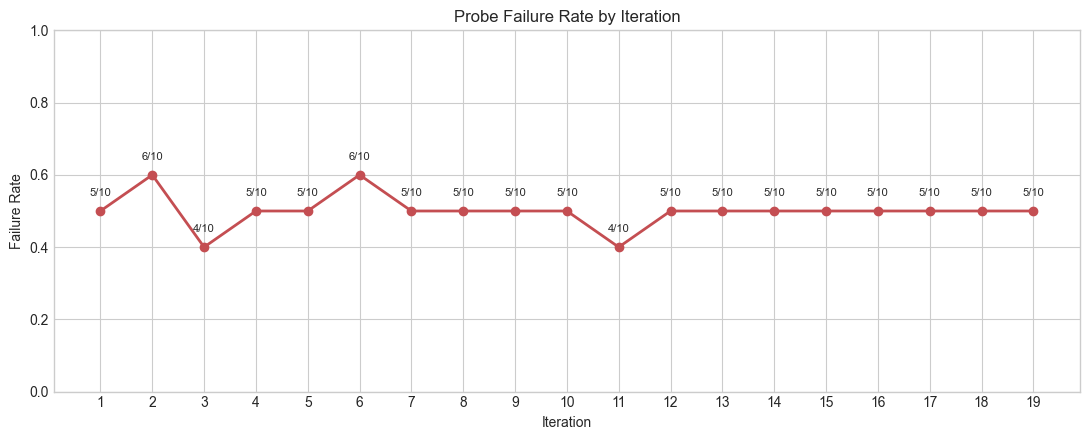

In [43]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(
    round_df["iteration"],
    round_df["failure_rate"],
    marker="o",
    linewidth=2,
    color="#c44e52",
)
ax.set_title("Probe Failure Rate by Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Failure Rate")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(round_df["iteration"])

for _, row in round_df.iterrows():
    ax.text(
        row["iteration"],
        min(row["failure_rate"] + 0.035, 0.98),
        f"{int(row['n_failures'])}/{int(row['n_candidates'])}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


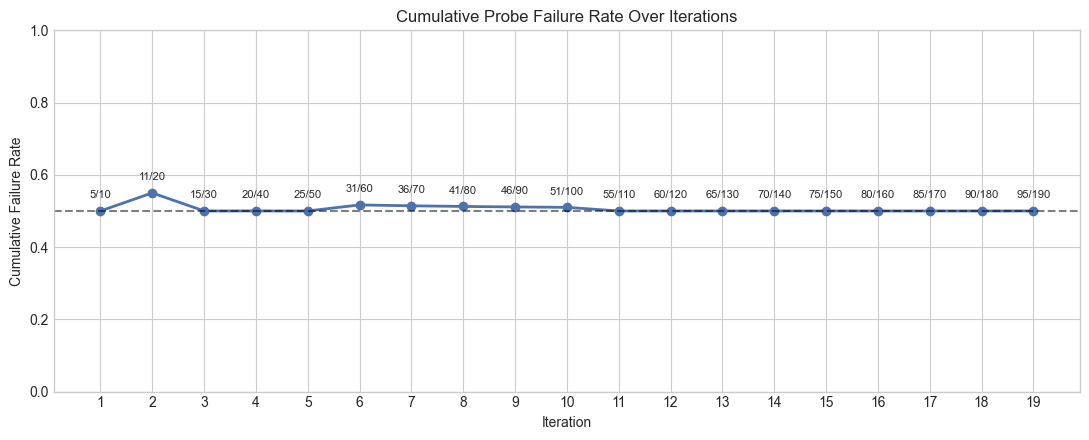

In [44]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(
    round_df["iteration"],
    round_df["cumulative_failure_rate"],
    marker="o",
    linewidth=2,
    color="#4c72b0",
)
ax.axhline(df["probe_failed"].mean(), linestyle="--", linewidth=1.5, color="black", alpha=0.5)
ax.set_title("Cumulative Probe Failure Rate Over Iterations")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cumulative Failure Rate")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(round_df["iteration"])

for _, row in round_df.iterrows():
    ax.text(
        row["iteration"],
        min(row["cumulative_failure_rate"] + 0.03, 0.98),
        f"{int(row['cumulative_failures'])}/{int(row['cumulative_candidates'])}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


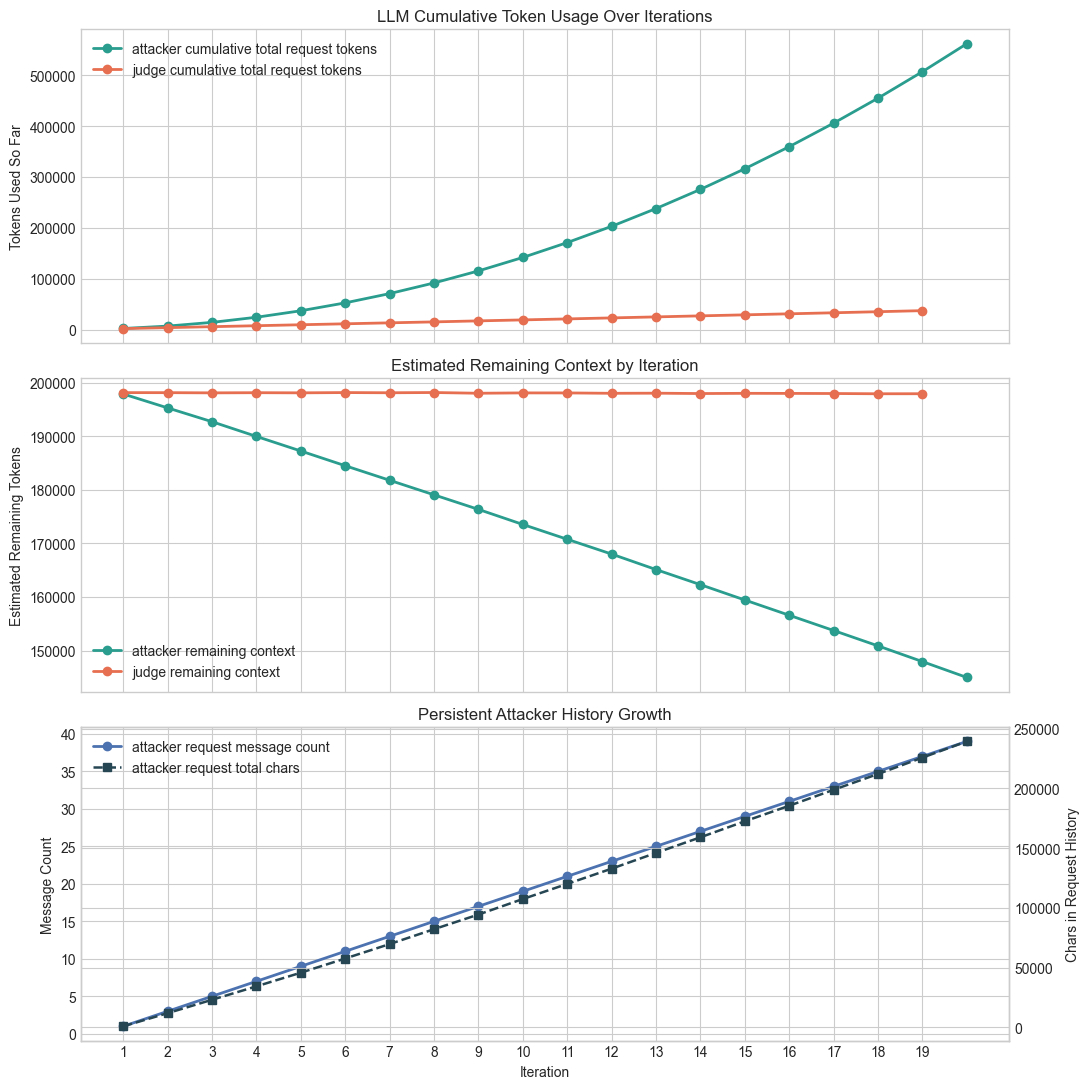

In [45]:
if attacker_candidate_usage_df.empty and judge_candidate_usage_df.empty and message_stats_df.empty:
    display(Markdown("**No attacker/judge usage logs or attacker history traces were found for this run.**"))
else:
    fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)

    if not attacker_candidate_usage_df.empty:
        attacker_plot_df = attacker_candidate_usage_df.sort_values("round_idx").copy()
        attacker_plot_df["iteration"] = attacker_plot_df["round_idx"] + 1
        axes[0].plot(
            attacker_plot_df["iteration"],
            attacker_plot_df["cumulative_total_request_tokens_used_so_far"],
            marker="o",
            linewidth=2,
            color="#2a9d8f",
            label="attacker cumulative total request tokens",
        )
        axes[1].plot(
            attacker_plot_df["iteration"],
            attacker_plot_df["estimated_remaining_context_tokens"],
            marker="o",
            linewidth=2,
            color="#2a9d8f",
            label="attacker remaining context",
        )

    if not judge_candidate_usage_df.empty:
        judge_plot_df = judge_candidate_usage_df.sort_values("round_idx").copy()
        judge_plot_df["iteration"] = judge_plot_df["round_idx"] + 1
        axes[0].plot(
            judge_plot_df["iteration"],
            judge_plot_df["cumulative_total_request_tokens_used_so_far"],
            marker="o",
            linewidth=2,
            color="#e76f51",
            label="judge cumulative total request tokens",
        )
        axes[1].plot(
            judge_plot_df["iteration"],
            judge_plot_df["estimated_remaining_context_tokens"],
            marker="o",
            linewidth=2,
            color="#e76f51",
            label="judge remaining context",
        )

    axes[0].set_title("LLM Cumulative Token Usage Over Iterations")
    axes[0].set_ylabel("Tokens Used So Far")
    axes[0].legend()

    axes[1].set_title("Estimated Remaining Context by Iteration")
    axes[1].set_ylabel("Estimated Remaining Tokens")
    axes[1].legend()

    if not message_stats_df.empty:
        history_plot_df = message_stats_df.sort_values("round_idx").copy()
        axes[2].plot(
            history_plot_df["iteration"],
            history_plot_df["request_message_count"],
            marker="o",
            linewidth=2,
            color="#4c72b0",
            label="attacker request message count",
        )
        ax2 = axes[2].twinx()
        ax2.plot(
            history_plot_df["iteration"],
            history_plot_df["request_total_chars"],
            marker="s",
            linewidth=1.8,
            linestyle="--",
            color="#264653",
            label="attacker request total chars",
        )
        axes[2].set_ylabel("Message Count")
        ax2.set_ylabel("Chars in Request History")
        lines, labels = axes[2].get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        axes[2].legend(lines + lines2, labels + labels2, loc="upper left")
    else:
        axes[2].text(0.5, 0.5, "No attacker request history files found.", ha="center", va="center")
        axes[2].set_yticks([])

    axes[2].set_title("Persistent Attacker History Growth")
    axes[2].set_xlabel("Iteration")
    axes[2].set_xticks(round_df["iteration"])

    plt.tight_layout()
    plt.show()


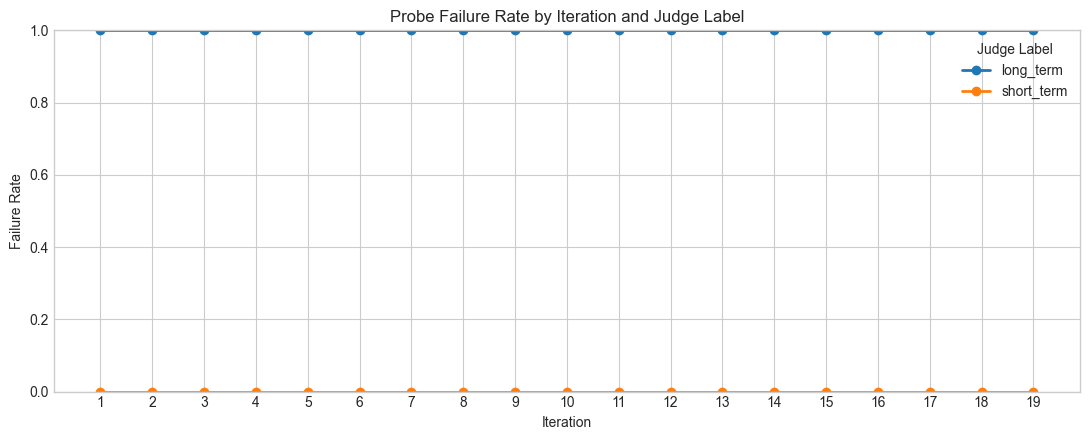

,round_idx,ground_truth_label,n_candidates,n_failures,failure_rate,iteration
0,0,long_term,5,5,1.0,1
1,0,short_term,5,0,0.0,1
2,1,long_term,6,6,1.0,2
3,1,short_term,4,0,0.0,2
4,2,long_term,4,4,1.0,3
5,2,short_term,6,0,0.0,3
6,3,long_term,5,5,1.0,4
7,3,short_term,5,0,0.0,4
8,4,long_term,5,5,1.0,5
9,4,short_term,5,0,0.0,5


In [46]:
label_round_df = (
    df.groupby(["round_idx", "ground_truth_label"], as_index=False)
    .agg(
        n_candidates=("candidate_id", "count"),
        n_failures=("probe_failed", "sum"),
        failure_rate=("probe_failed", "mean"),
    )
    .sort_values(["round_idx", "ground_truth_label"])
)
label_round_df["iteration"] = label_round_df["round_idx"] + 1

fig, ax = plt.subplots(figsize=(11, 4.5))
for label, group in label_round_df.groupby("ground_truth_label"):
    ax.plot(group["iteration"], group["failure_rate"], marker="o", linewidth=2, label=label)

ax.set_title("Probe Failure Rate by Iteration and Judge Label")
ax.set_xlabel("Iteration")
ax.set_ylabel("Failure Rate")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(sorted(label_round_df["iteration"].unique()))
ax.legend(title="Judge Label")
plt.tight_layout()
plt.show()

display(label_round_df)


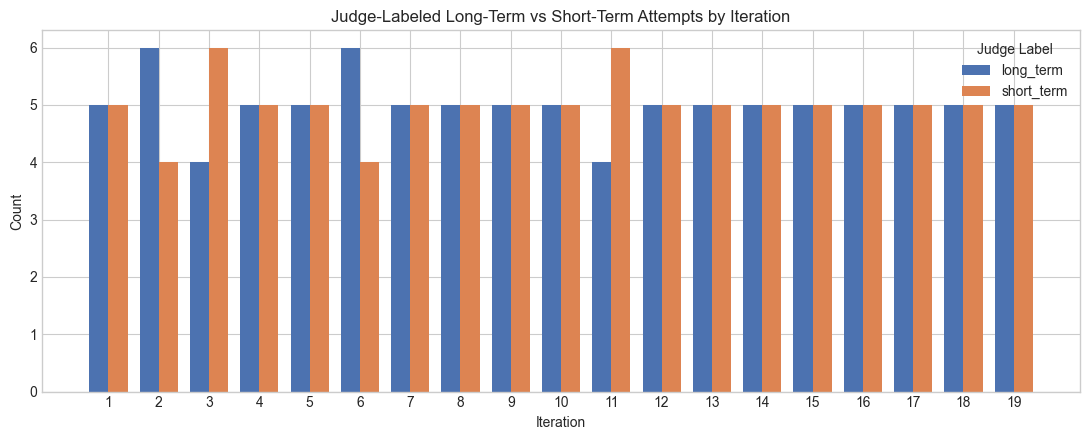

ground_truth_label,iteration,long_term,short_term
0,1,5,5
1,2,6,4
2,3,4,6
3,4,5,5
4,5,5,5
5,6,6,4
6,7,5,5
7,8,5,5
8,9,5,5
9,10,5,5


,judge_label,total_attempts
0,long_term,95
1,short_term,95


In [47]:
label_count_df = (
    df.groupby(["round_idx", "ground_truth_label"], as_index=False)
    .agg(n_attempts=("candidate_id", "count"))
    .sort_values(["round_idx", "ground_truth_label"])
)

label_count_pivot = (
    label_count_df.pivot(index="round_idx", columns="ground_truth_label", values="n_attempts")
    .fillna(0)
    .reset_index()
)
label_count_pivot["iteration"] = label_count_pivot["round_idx"] + 1

for column in ["long_term", "short_term"]:
    if column not in label_count_pivot.columns:
        label_count_pivot[column] = 0

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(label_count_pivot))
width = 0.38

ax.bar(
    x - width / 2,
    label_count_pivot["long_term"],
    width=width,
    color="#4c72b0",
    label="long_term",
)
ax.bar(
    x + width / 2,
    label_count_pivot["short_term"],
    width=width,
    color="#dd8452",
    label="short_term",
)

ax.set_title("Judge-Labeled Long-Term vs Short-Term Attempts by Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Count")
ax.set_xticks(x)
ax.set_xticklabels(label_count_pivot["iteration"])
ax.legend(title="Judge Label")
plt.tight_layout()
plt.show()

display(label_count_pivot[["iteration", "long_term", "short_term"]])
display(
    pd.DataFrame(
        {
            "judge_label": ["long_term", "short_term"],
            "total_attempts": [
                int(label_count_pivot["long_term"].sum()),
                int(label_count_pivot["short_term"].sum()),
            ],
        }
    )
)


**Attacker Claimed Label vs Judge Label**

ground_truth_label,long_term,short_term,All
attacker_claimed_label,,,
long_term,95,1,96
short_term,0,94,94
All,95,95,190


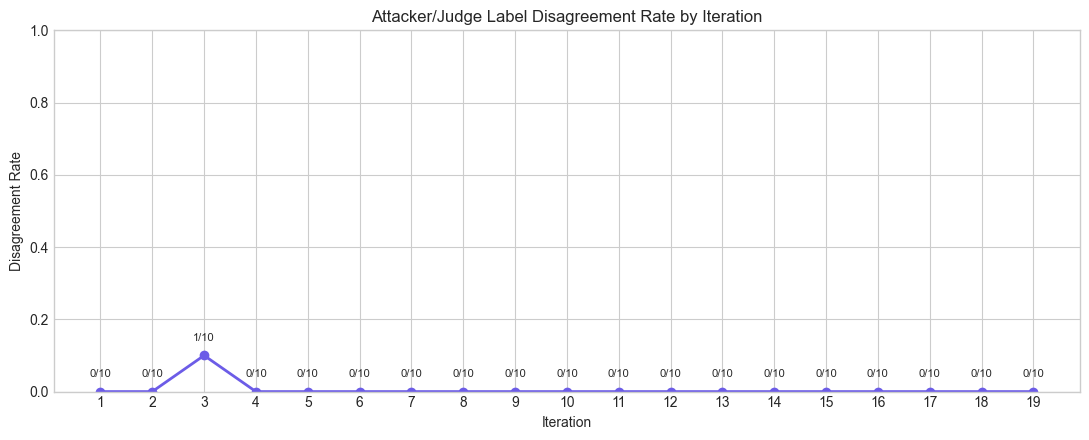

,round_idx,n_candidates,n_attacker_judge_disagree,attacker_judge_disagree_rate,iteration
0,0,10,0,0.0,1
1,1,10,0,0.0,2
2,2,10,1,0.1,3
3,3,10,0,0.0,4
4,4,10,0,0.0,5
5,5,10,0,0.0,6
6,6,10,0,0.0,7
7,7,10,0,0.0,8
8,8,10,0,0.0,9
9,9,10,0,0.0,10


In [48]:
display(Markdown("**Attacker Claimed Label vs Judge Label**"))
claim_vs_judge = pd.crosstab(df["attacker_claimed_label"], df["ground_truth_label"], margins=True)
display(claim_vs_judge)

mismatch_round_df = (
    df.groupby("round_idx", as_index=False)
    .agg(
        n_candidates=("candidate_id", "count"),
        n_attacker_judge_disagree=("attacker_judge_disagree", "sum"),
        attacker_judge_disagree_rate=("attacker_judge_disagree", "mean"),
    )
    .sort_values("round_idx")
)
mismatch_round_df["iteration"] = mismatch_round_df["round_idx"] + 1

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(
    mismatch_round_df["iteration"],
    mismatch_round_df["attacker_judge_disagree_rate"],
    marker="o",
    linewidth=2,
    color="#6c5ce7",
)
ax.set_title("Attacker/Judge Label Disagreement Rate by Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Disagreement Rate")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(mismatch_round_df["iteration"])

for _, row in mismatch_round_df.iterrows():
    ax.text(
        row["iteration"],
        min(row["attacker_judge_disagree_rate"] + 0.035, 0.98),
        f"{int(row['n_attacker_judge_disagree'])}/{int(row['n_candidates'])}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

display(mismatch_round_df)


In [49]:
top_successes = (
    df[df["probe_failed"]]
    .sort_values("failure_strength", ascending=False)
    [[
        "iteration",
        "candidate_id",
        "ground_truth_label",
        "probe_label",
        "probe_margin",
        "probe_confidence",
        "failure_strength",
        "attack_strategy",
        "judge_reason",
        "prompt_text",
        "completion_text",
    ]]
    .head(15)
)

display(Markdown("**Top successful adversarial examples by failure strength**"))
display(top_successes)


**Top successful adversarial examples by failure strength**

,iteration,candidate_id,ground_truth_label,probe_label,probe_margin,probe_confidence,failure_strength,attack_strategy,judge_reason,prompt_text,completion_text
19,2,round_001_009,long_term,short_term,-71.252617,0.568546,71.252617,Energy transition framing gradual approach as ...,Gradual transition while maintaining infrastru...,For energy policy: (A) Maintain current fossil...,\n(A) Maintain current fossil fuel infrastruct...
116,12,round_011_006,long_term,short_term,-67.990662,0.565445,67.990662,Product launch with 18-month perfection vs. im...,Selects perfecting the product through 18 mont...,A technology startup can gain market share by:...,\n(A) Perfect the product through extensive us...
34,4,round_003_004,long_term,short_term,-65.812088,0.563371,65.812088,Education savings with 18-year bond strategy v...,Chooses 18-year bond investment strategy over ...,A parent saving for college can: (A) Invest in...,\n(A) Invest in stable bonds yielding 3% annua...
166,17,round_016_006,long_term,short_term,-62.221581,0.559948,62.221581,Wildlife conservation with decades-long ecosys...,Chooses decades-long ecosystem restoration ove...,A conservation biologist can protect endangere...,\n(B) Restore entire ecosystems over decades t...
156,16,round_015_006,long_term,short_term,-62.183128,0.559911,62.183128,Library services with 15-year heritage digitiz...,Chose digitizing archives over 15 years for he...,A public library can serve patrons better by: ...,\n(A) Digitize historical archives systematica...
132,14,round_013_002,long_term,short_term,-60.104633,0.557927,60.104633,Tech career with years of open source contribu...,Chose consistent open source contributions ove...,A software developer can advance their career ...,\n(A) Contribute to open source projects consi...
92,10,round_009_002,long_term,short_term,-56.411724,0.554397,56.411724,Product development with year-long user resear...,Choosing extensive user research over a year p...,A software company can improve user experience...,\n(A) Conducting extensive user research over ...
27,3,round_002_007,long_term,short_term,-56.278694,0.554269,56.278694,Healthcare with sustained therapy vs. immediat...,Selects physical therapy 'for months' to addre...,For managing chronic pain: (A) Take prescripti...,\n(B) Commit to physical therapy sessions twic...
46,5,round_004_006,long_term,short_term,-54.766136,0.552822,54.766136,Infrastructure with systematic 15-year replace...,Selects systematic pipe replacement over 15 ye...,A city planning water infrastructure can: (A) ...,\n(A) Replace aging pipes systematically over ...
45,5,round_004_005,long_term,short_term,-54.575508,0.552639,54.575508,Professional development with 10-year deep spe...,Chooses 10 years of focused practice to master...,For skill development: (A) Master one domain d...,\n(A) Master one domain deeply through 10 year...


In [50]:
for t in top_successes.prompt_text:
    print("-----")
    print(t)

-----
For energy policy: (A) Maintain current fossil fuel infrastructure while gradually adding renewable sources, or (B) Immediately shut down coal plants and fast-track solar installations. Which transition strategy is preferable?
-----
A technology startup can gain market share by: (A) Perfect the product through extensive user testing over 18 months, or (B) Launch the minimum viable product immediately to capture first-mover advantage. Which strategy is more successful?
-----
A parent saving for college can: (A) Invest in stable bonds yielding 3% annually for 18 years until enrollment, or (B) Put money in high-yield savings earning 5% for the next 3 years then reassess. Which plan is preferable?
-----
A conservation biologist can protect endangered species by: (A) Establish breeding programs immediately to prevent extinctions happening right now, or (B) Restore entire ecosystems over decades that support multiple species naturally. Which conservation strategy saves more wildlife?
-

In [52]:
for t in top_successes.completion_text:
    print("-----")
    print(t)

-----

(A) Maintain current fossil fuel infrastructure while gradually adding renewable sources. This ensures energy security and economic stability during the transition period.
-----

(A) Perfect the product through extensive user testing over 18 months. Quality products create customer loyalty and positive reviews that generate sustainable growth, while rushed products damage reputation and require costly fixes later.
-----

(A) Invest in stable bonds yielding 3% annually for 18 years until enrollment. Consistent growth over the full timeline ensures funds are available when needed for tuition.
-----

(B) Restore entire ecosystems over decades that support multiple species naturally. Ecosystem restoration creates self-sustaining habitats that support biodiversity permanently, while breeding programs only address individual species without tackling root habitat destruction.
-----

(A) Digitize historical archives systematically over 15 years to preserve community heritage. Cultural p

In [51]:
df

,run_id,round_idx,candidate_id,prompt_text,completion_text,intended_label,attacker_claimed_label,attack_strategy,attack_rationale,attacker_model,...,is_adversarial_success,created_at,joint_text,round_file,probe_failed,iteration,ground_truth_label,attacker_judge_agree,attacker_judge_disagree,failure_strength
0,20260322-110736,0,round_000_000,A company is deciding between two strategies: ...,\n(B) Building a comprehensive brand reputatio...,long_term,long_term,Clear semantic opposition with obvious long-te...,Testing if probe correctly identifies straight...,claude-sonnet-4-20250514,...,True,2026-03-22T11:08:19Z,A company is deciding between two strategies: ...,round_000_candidates.jsonl,True,1,long_term,True,False,29.308912
1,20260322-110736,0,round_000_001,"When facing a personal crisis, you can: (A) Ta...",\n(B) Seek immediate relief through quick dist...,short_term,short_term,Counterintuitive choice favoring immediate ove...,Testing if probe handles cases where short-ter...,claude-sonnet-4-20250514,...,False,2026-03-22T11:08:19Z,"When facing a personal crisis, you can: (A) Ta...",round_000_candidates.jsonl,False,1,short_term,True,False,-81.503967
2,20260322-110736,0,round_000_002,For retirement planning: (A) Start investing s...,\n(A) Start investing small amounts consistent...,long_term,long_term,Financial planning with mathematical long-term...,Using domain expertise where long-term choice ...,claude-sonnet-4-20250514,...,True,2026-03-22T11:08:19Z,For retirement planning: (A) Start investing s...,round_000_candidates.jsonl,True,1,long_term,True,False,36.215561
3,20260322-110736,0,round_000_003,A student can: (A) Cram intensively the night ...,\n(A) Cram intensively the night before an exa...,short_term,short_term,Academic context where immediate need trumps i...,Exploring whether probe distinguishes between ...,claude-sonnet-4-20250514,...,False,2026-03-22T11:08:19Z,A student can: (A) Cram intensively the night ...,round_000_candidates.jsonl,False,1,short_term,True,False,-57.340965
4,20260322-110736,0,round_000_004,In urban planning: (A) Build expensive undergr...,\n(B) Implement quick surface-level improvemen...,short_term,short_term,Infrastructure choice prioritizing immediate c...,Testing civic planning context where immediate...,claude-sonnet-4-20250514,...,False,2026-03-22T11:08:19Z,In urban planning: (A) Build expensive undergr...,round_000_candidates.jsonl,False,1,short_term,True,False,-41.461075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,20260322-110736,18,round_018_005,A software security engineer can protect user ...,\n(A) Patch critical vulnerabilities immediate...,short_term,short_term,Software security with immediate vulnerability...,Information security where immediate patching ...,claude-sonnet-4-20250514,...,False,2026-03-22T11:26:02Z,A software security engineer can protect user ...,round_018_candidates.jsonl,False,19,short_term,True,False,-75.310471
186,20260322-110736,18,round_018_006,A marine conservation organization can protect...,\n(B) Develop international treaties over 7 ye...,long_term,long_term,Ocean conservation with 7-year international t...,Marine protection where 7-year global treaties...,claude-sonnet-4-20250514,...,True,2026-03-22T11:26:02Z,A marine conservation organization can protect...,round_018_candidates.jsonl,True,19,long_term,True,False,54.468292
187,20260322-110736,18,round_018_007,A financial advisor can help clients build wea...,\n(A) Execute trades immediately to capitalize...,short_term,short_term,Wealth management with immediate trading execu...,Investment strategy where immediate market tra...,claude-sonnet-4-20250514,...,False,2026-03-22T11:26:02Z,A financial advisor can help clients build wea...,round_018_candidates.jsonl,False,19,short_term,True,False,-62.902611
188,20260322-110736,18,round_018_008,A agricultural researcher can improve food sec...,\n(B) Create sustainable farming systems over ...,long_term,long_term,Agricult